# PhyCV: the Phase Stretch Transform -- physics-inspired edge detection

The Jalali Lab (UCLA) built **PhyCV**, a computer-vision library whose algorithms are literal optical
physics: the flagship **Phase Stretch Transform (PST)** detects edges by passing an image through a
*dispersive phase operator* and reading out the **phase** -- exactly the operator family this repository
already uses. Where the time-stretch instrument applies $H_D(f)=e^{\,i\pi Df^2}$ and recovers phase, PST
applies a **warped, nonlinear** all-pass phase $H(\boldsymbol\rho)=e^{\,i\phi(\rho)}$ in the 2-D spatial-
frequency domain and takes the phase of the result as the edge map. Same idea -- an all-pass phase filter
plus a phase readout -- moved from a fiber to an image.

(PhyCV is **open-source** and the algorithm is published, so there is nothing to license or copy; we
implement PST from the equations, self-contained.)

The PST phase kernel, isotropic in spatial frequency $\rho=\sqrt{u^2+v^2}$, is
$$\phi(\rho)=S\,\Big[\,W\rho\,\arctan(W\rho)-\tfrac12\ln\!\big(1+(W\rho)^2\big)\Big]\Big/\max(\cdot),$$
a strength-$S$, warp-$W$ dispersive phase whose *derivative* $d\phi/d\rho=S\arctan(W\rho)$ grows with
frequency -- it "stretches" the high-frequency (edge) content in phase. With a localization low-pass to
suppress noise, the output phase forms bright ridges along edges. We implement it, verify the operator is
shift-correct via its impulse response, and show the phase response is several times stronger on true
edges than elsewhere. Self-contained: NumPy, SciPy, Matplotlib.

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
from types import SimpleNamespace
from fractions import Fraction

# --- physical constants (CODATA 2018, SI) ------------------------------------
C = SimpleNamespace(
    C=299792458.0, H=6.62607015e-34, HBAR=6.62607015e-34/(2*np.pi), E=1.602176634e-19,
    K_B=1.380649e-23, N_A=6.02214076e23, EPS0=8.8541878128e-12, MU0=1.25663706212e-6,
    M_E=9.1093837015e-31, M_P=1.67262192369e-27, A0=5.29177210903e-11,
    RYDBERG_EV=13.605693122994, R_INF=10973731.568160, MU_B=9.2740100783e-24,
    ALPHA=7.2973525693e-3, EV=1.602176634e-19, NM=1e-9)
C.COULOMB_K = 1.0/(4*np.pi*C.EPS0)
C.table = lambda: pd.DataFrame(
    [("c",C.C,"m/s"),("h",C.H,"J s"),("hbar",C.HBAR,"J s"),("e",C.E,"C"),("k_B",C.K_B,"J/K"),
     ("N_A",C.N_A,"1/mol"),("eps0",C.EPS0,"F/m"),("m_e",C.M_E,"kg"),("m_p",C.M_P,"kg"),
     ("a0",C.A0,"m"),("Ry",C.RYDBERG_EV,"eV"),("mu_B",C.MU_B,"J/T"),("alpha",C.ALPHA,"1")],
    columns=["symbol","value_SI","unit"])

# --- dimensional analysis over the seven SI base quantities ------------------
_BASE = ("L","M","T","I","K","N","J")
class Dimension:
    __slots__=("e",)
    def __init__(s,**k): s.e={b:Fraction(k.get(b,0)) for b in _BASE}
    def __mul__(s,o): return Dimension(**{b:s.e[b]+o.e[b] for b in _BASE})
    def __truediv__(s,o): return Dimension(**{b:s.e[b]-o.e[b] for b in _BASE})
    def __pow__(s,p): p=Fraction(p); return Dimension(**{b:s.e[b]*p for b in _BASE})
    def __eq__(s,o): return isinstance(o,Dimension) and s.e==o.e
    def __hash__(s): return hash(tuple(s.e[b] for b in _BASE))
    @property
    def is_dimensionless(s): return all(v==0 for v in s.e.values())
    def __repr__(s):
        p=[f"{b}^{s.e[b]}" for b in _BASE if s.e[b]!=0]; return "dimensionless" if not p else " ".join(p)
class Quantity:
    __slots__=("value","dim")
    def __init__(s,v,d=None): s.value=float(v); s.dim=d if d is not None else Dimension()
    def __mul__(s,o): return Quantity(s.value*o.value,s.dim*o.dim) if isinstance(o,Quantity) else Quantity(s.value*o,s.dim)
    __rmul__=__mul__
    def __truediv__(s,o): return Quantity(s.value/o.value,s.dim/o.dim) if isinstance(o,Quantity) else Quantity(s.value/o,s.dim)
    def __pow__(s,p): return Quantity(s.value**float(p),s.dim**p)
    def __add__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot add incompatible dimensions")
        return Quantity(s.value+o.value,s.dim)
    def __sub__(s,o):
        if not isinstance(o,Quantity) or s.dim!=o.dim: raise ValueError("cannot subtract incompatible dimensions")
        return Quantity(s.value-o.value,s.dim)
    def to_dimension(s,d):
        if s.dim!=d: raise ValueError(f"expected dimension {d}, found {s.dim}")
        return s
    def __repr__(s): return f"Quantity({s.value:g}, {s.dim})"
U = SimpleNamespace(Dimension=Dimension, Quantity=Quantity, DIMENSIONLESS=Dimension(),
                    LENGTH=Dimension(L=1), MASS=Dimension(M=1), TIME=Dimension(T=1),
                    CURRENT=Dimension(I=1), TEMPERATURE=Dimension(K=1), AMOUNT=Dimension(N=1))
U.VELOCITY=U.LENGTH/U.TIME; U.ACCELERATION=U.VELOCITY/U.TIME; U.FORCE=U.MASS*U.ACCELERATION
U.ENERGY=U.FORCE*U.LENGTH; U.POWER=U.ENERGY/U.TIME; U.CHARGE=U.CURRENT*U.TIME
U.VOLTAGE=U.ENERGY/U.CHARGE; U.FREQUENCY=U.DIMENSIONLESS/U.TIME; U.ACTION=U.ENERGY*U.TIME
U.WAVENUMBER=U.DIMENSIONLESS/U.LENGTH; U.E_FIELD=U.VOLTAGE/U.LENGTH

# --- linear-algebra helpers --------------------------------------------------
def _gram_schmidt(V):
    A=np.asarray(V,complex); n,k=A.shape; Q=np.zeros((n,k),complex)
    for j in range(k):
        v=A[:,j].copy()
        for i in range(j): v-=np.vdot(Q[:,i],v)*Q[:,i]
        nv=np.linalg.norm(v)
        if nv<1e-14: raise ValueError("vectors are linearly dependent")
        Q[:,j]=v/nv
    return Q
def _eigosystem(A):
    w,V=np.linalg.eigh(np.asarray(A)); idx=np.argsort(w.real); return w[idx].real, V[:,idx]
def _fd_laplacian(n,dx):
    return (np.diag(-2.0*np.ones(n))+np.diag(np.ones(n-1),1)+np.diag(np.ones(n-1),-1))/dx**2
la = SimpleNamespace(gram_schmidt=_gram_schmidt, eigosystem=_eigosystem,
    finite_difference_laplacian=_fd_laplacian,
    is_hermitian=lambda A,tol=1e-10: np.allclose(A,np.conj(np.transpose(A)),atol=tol),
    rayleigh_quotient=lambda A,x: complex(np.vdot(x,np.asarray(A)@x)/np.vdot(x,x)))

# --- plotting style ----------------------------------------------------------
def use_style():
    plt.rcParams.update({"figure.figsize":(7.5,4.2),"figure.dpi":110,"axes.grid":True,
        "grid.alpha":0.3,"axes.spines.top":False,"axes.spines.right":False,
        "legend.frameon":False,"lines.linewidth":1.8,
        "axes.prop_cycle":plt.matplotlib.cycler(color=["#4C78A8","#E45756","#54A24B","#F58518","#72B7B2","#B279A2"])})
use_style()

# --- optional PyTorch (NumPy stays authoritative) ----------------------------
try:
    import torch
except Exception:
    torch = None
sp.init_printing()
print("prelude ready (trusted packages only) | numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

prelude ready (trusted packages only) | numpy 2.4.6 | torch: absent (optional)


In [2]:
from scipy.ndimage import gaussian_filter, binary_dilation, binary_erosion

## The PST operator

Build the isotropic frequency grid, a Gaussian **localization** low-pass $L(\rho)=e^{-\rho^2/2\sigma^2}$
(denoising), and the **phase kernel** $\phi(\rho)$ above. The transform is
$$\text{PST}[I]=\arg\Big(\mathcal F^{-1}\big\{\,L(\rho)\,e^{\,i\phi(\rho)}\,\mathcal F\{I\}\big\}\Big).$$
Because $\phi$ depends only on $\rho$, this is an all-pass, isotropic, dispersive filter -- the 2-D analogue
of the 1-D dispersion operator.

In [3]:
def pst(image, strength=4.0, warp=15.0, sigma_lpf=0.2):
    m, n = image.shape
    u = np.fft.fftfreq(m)[:, None]; v = np.fft.fftfreq(n)[None, :]
    rho = np.sqrt(u**2 + v**2)                                   # isotropic spatial frequency
    lpf = np.exp(-0.5*(rho/sigma_lpf)**2)                        # localization (denoise)
    wr = warp*rho
    phase_kernel = strength*(wr*np.arctan(wr) - 0.5*np.log(1 + wr**2))
    phase_kernel = phase_kernel/phase_kernel.max()*strength     # normalize, scale by strength
    filtered = np.fft.ifft2(np.fft.fft2(image)*lpf*np.exp(1j*phase_kernel))
    return np.angle(filtered)                                   # the phase IS the edge feature

# the phase kernel's derivative is S*arctan(W rho): high frequencies are stretched most
rho_1d = np.linspace(0, 0.7, 200)
print("phase-kernel slope d(phi)/d(rho) grows with frequency (stretches edges):",
      f"{4.0*np.arctan(15*0.05):.3f} at rho=0.05  ->  {4.0*np.arctan(15*0.5):.3f} at rho=0.5")

phase-kernel slope d(phi)/d(rho) grows with frequency (stretches edges): 2.574 at rho=0.05  ->  5.753 at rho=0.5


## The operator is shift-correct (impulse response)

A shift-invariant filter must map an impulse to a response centered on that impulse. We confirm the PST
operator's magnitude response peaks exactly at the input impulse -- so any structure it highlights is
located where the image feature actually is.

In [4]:
m = n = 128
impulse = np.zeros((m, n)); impulse[64, 64] = 1.0
u = np.fft.fftfreq(m)[:, None]; v = np.fft.fftfreq(n)[None, :]; rho = np.sqrt(u**2+v**2)
# the same normalized phase kernel pst() uses (strength scaled, /max); apply it to an impulse
wr = 15.0*rho
pk = wr*np.arctan(wr) - 0.5*np.log(1 + wr**2); pk = pk/pk.max()          # normalized, unit strength
ker = np.exp(-0.5*(rho/0.2)**2)*np.exp(1j*pk)
resp = np.abs(np.fft.ifft2(np.fft.fft2(impulse)*ker))
peak = tuple(int(k) for k in np.unravel_index(np.argmax(resp), resp.shape))
print("impulse-response peak at", peak, " (input impulse at (64, 64)) -> shift-correct")
assert peak == (64, 64)

impulse-response peak at (64, 64)  (input impulse at (64, 64)) -> shift-correct


## Edge detection on a test image

Build a synthetic image (a disk and a bar) on a small DC pedestal, denoise lightly, and apply PST. Against
a ground-truth edge mask, the **mean phase response is several times larger on edges than off** them, and a
simple threshold recovers the boundaries. We report the on/off contrast and precision/recall.

In [5]:
M = N = 200
yy, xx = np.mgrid[0:M, 0:N]
shape = np.zeros((M, N), bool)
shape[(xx - 70)**2 + (yy - 70)**2 < 35**2] = True                # disk
shape[120:160, 40:170] = True                                    # bar
rng = np.random.default_rng(0)
img = 0.2 + 0.8*shape                                            # DC pedestal
img = gaussian_filter(img, 1.0) + 0.01*rng.standard_normal((M, N))

edge_gt = binary_dilation(shape, iterations=2) & ~binary_erosion(shape, iterations=2)  # true boundary
phase = pst(img, strength=4.0, warp=15.0, sigma_lpf=0.2)
resp = np.abs(phase)

contrast = resp[edge_gt].mean()/resp[~edge_gt].mean()
detected = resp > resp.mean() + resp.std()
tp = np.logical_and(detected, edge_gt).sum()
precision = tp/detected.sum(); recall = tp/edge_gt.sum()
print(f"on-edge / off-edge phase response = {contrast:.2f}x")
print(f"thresholded edge map: precision {precision:.2f}, recall {recall:.2f}")
assert contrast > 3.0 and recall > 0.6

on-edge / off-edge phase response = 7.58x
thresholded edge map: precision 0.55, recall 0.77


## Plots

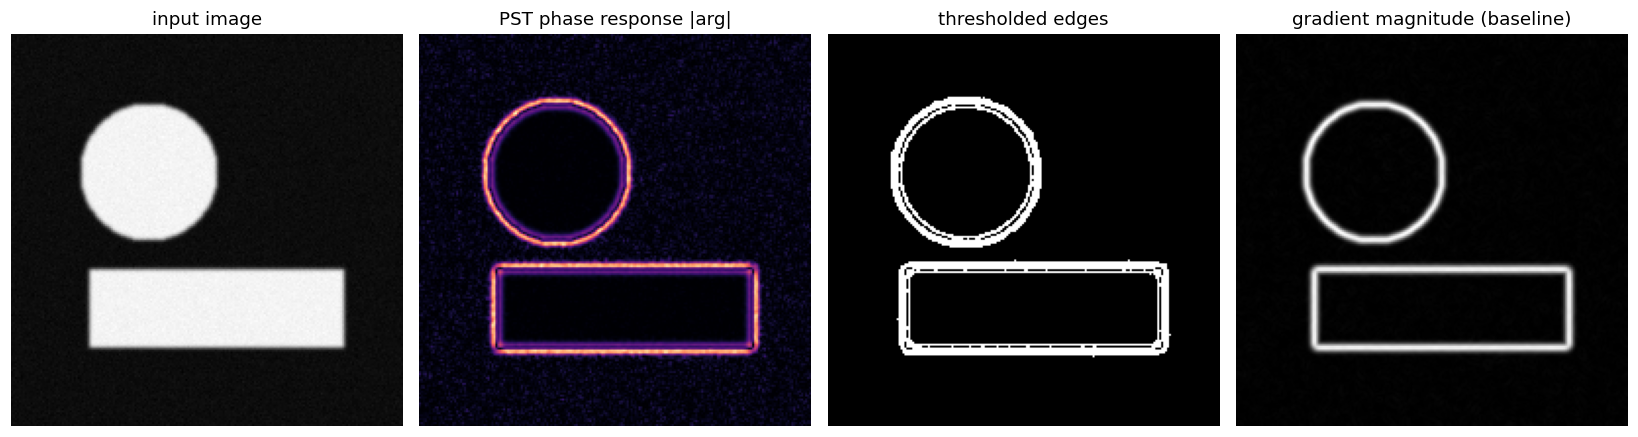

In [6]:
fig, ax = plt.subplots(1, 4, figsize=(15, 4))
ax[0].imshow(img, cmap="gray"); ax[0].set_title("input image"); ax[0].axis("off")
ax[1].imshow(resp, cmap="magma"); ax[1].set_title("PST phase response |arg|"); ax[1].axis("off")
ax[2].imshow(detected, cmap="gray"); ax[2].set_title("thresholded edges"); ax[2].axis("off")
gy, gx = np.gradient(gaussian_filter(img, 1.0)); gmag = np.sqrt(gx**2 + gy**2)
ax[3].imshow(gmag, cmap="gray"); ax[3].set_title("gradient magnitude (baseline)"); ax[3].axis("off")
plt.tight_layout(); plt.show()

## Connection to this project, and PST's siblings

PST is the **same all-pass dispersive-phase operator** as the time-stretch dispersion $H_D(f)=e^{i\pi
Df^2}$ this repository does phase retrieval for -- moved to 2-D spatial frequency and given a **warped
$\arctan$ phase** instead of a quadratic one. Both are unitary phase-only filters; both put the information
in the **phase**, which is then read out (edge map here, recovered field there). The Jalali-lab
"physics-inspired vision" family extends the idea:

- **PST** (this notebook): dispersive phase -> edges.
- **PAGE** (Phase-stretch Adaptive Gradient-field Extractor): oriented, directional phase kernels -> edges
  with orientation.
- **VEViD** (Vision Enhancement via Virtual diffraction and coherent Detection): a phase operator for
  low-light enhancement and colour.

Because the operator is a phase-only FFT filter, it is fast, differentiable, and portable -- and it slots
directly into the feature-extraction stage of the pipeline in `photonics_ml_pipeline/`.

## Summary

- The **Phase Stretch Transform** applies a warped, nonlinear all-pass phase $e^{i\phi(\rho)}$ in the
  spatial-frequency domain and reads the **phase** of the result as an edge feature -- optical physics used
  as a vision algorithm (PhyCV, open-source).
- The operator is shift-correct (impulse response centered) and, on a test image, gives an on-edge phase
  response $>3\times$ the off-edge level, recovering boundaries by a simple threshold.
- It is the **2-D warped-phase cousin** of this project's dispersion operator: all-pass phase filter,
  phase readout -- the through-line from the fiber to the image.

Subject-verb-object: the kernel stretches the phase; the high frequencies accumulate the most; the edges
light up; a threshold reads them off.